<a href="https://colab.research.google.com/github/kavinkumarManielayaperumal/Toy-Model-for-Gaussian-Mixture-in-Traffic-Scenario-Group-Project./blob/main_toy/model_that_runs_in_core_features_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  ***Necessary libraries***

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive




# ***Standardize data***

In [ ]:


# Define the file path for the input CSV file
file_path = r'F:\gaussian mixture\for_data\highD-dataset-v1.0\data\01_tracks.csv'

# Load the dataset
data = pd.read_csv(file_path)

# Columns to standardize
columns_to_standardize = ['x', 'y', 'xVelocity', 'yVelocity', 'xAcceleration', 'yAcceleration']

# Compute mean and standard deviation for the selected columns
mean_std = data[columns_to_standardize].agg(['mean', 'std'])

# Standardize the selected columns using Z-score formula
data_standardized = data.copy()
for col in columns_to_standardize:
    data_standardized[col] = (data[col] - mean_std.loc['mean', col]) / mean_std.loc['std', col]

# Print the first few rows of the standardized dataset (for verification)
print(data_standardized.head())

# Define the output directory and file path
output_folder = r'F:\gaussian mixture\standardized_data'
output_file_path = os.path.join(output_folder, 'standardized_01_tracks.csv')

# Create the folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    print(f"Created new folder: {output_folder}")

# Save the standardized dataset to a new CSV file
data_standardized.to_csv(output_file_path, index=False)
print(f"Standardized data saved to: {output_file_path}")


# ***Model***


*   Initialization

*   Define E-step (Expectation)
*   Define M-step (Maximization)


*   Combine into EM Algorithm


*   Assign Clusters and Visualize






In [2]:
# Load Standardized File (Before Initialization) for the single file
# Load the standardized file
drive.mount('/content/drive')
file_path =r"/content/drive/My Drive/for data/standardized_01(core features)_tracks.csv"
data = pd.read_csv(file_path)
# Convert to NumPy array (optional, if not working with pandas)
X = data.values  # X is the standardized data (n_samples, n_features)

Mounted at /content/drive


## ***Initialization***

In [3]:
import numpy as np

# Function to initialize the parameters
def initialize_parameters(X, num_clusters):
    """
    Initializes the parameters for GMM.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).

    Returns:
        means (numpy.ndarray): Initial means for each cluster of shape (num_clusters, n_features).
        covariances (list of numpy.ndarray): Initial covariance matrices for each cluster.
        weights (numpy.ndarray): Initial weights for each cluster of shape (num_clusters,).
    """
    np.random.seed(42)  # For reproducibility
    n_samples, n_features = X.shape

    # Step 1: Initialize means by randomly sampling data points
    initial_means = X[np.random.choice(n_samples, num_clusters, replace=False)]

    # Step 2: Initialize covariances as identity matrices
    initial_covariances = [np.eye(n_features) for _ in range(num_clusters)]

    # Step 3: Initialize weights equally
    initial_weights = np.ones(num_clusters) / num_clusters

    return initial_means, initial_covariances, initial_weights

# Example usage:
# Assuming `data_standardized` is your standardized dataset
num_clusters = 3  # Number of clusters (e.g., Left, Straight, Right)
means, covariances, weights = initialize_parameters(X, num_clusters)

# Print the initialized parameters
print("Initial Means:\n", means)
print("\nInitial Covariances:\n", covariances)
print("\nInitial Weights:\n", weights)


Initial Means:
 [[ 1.72535113  1.35343136  0.89109339  0.17491752  0.01779814  0.39454963]
 [-1.47128414 -1.16196731 -0.82194716 -0.87524276 -0.21849952  0.15073248]
 [-0.02688552  1.38934332  0.82262444  0.00910274 -0.65733803 -0.58071897]]

Initial Covariances:
 [array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]]), array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]]), array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]])]

Initial Weights:
 [0.33333333 0.33333333 0.33333333]


# ***Define E-step (Expectation)***

In [57]:
# E-step: Calculate posterior probabilities (responsibilities)
def e_step(X, means, covariances, weights, num_clusters):
    n_samples, n_features = X.shape
    responsibilities = np.zeros((n_samples, num_clusters))

    for k in range(num_clusters):
        diff = X - means[k]
        cov_inv = np.linalg.inv(covariances[k])
        exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariances[k]))
        responsibilities[:, k] = weights[k] * np.exp(exponent) / normalization

    # Normalize responsibilities
    responsibilities = responsibilities / responsibilities.sum(axis=1, keepdims=True)
    return responsibilities


# ***Define M-step (Maximization)***

In [58]:
# M-step: Update parameters
def m_step(X, responsibilities, num_clusters):
    n_samples, n_features = X.shape
    weights = responsibilities.sum(axis=0) / n_samples
    means = np.zeros((num_clusters, n_features))
    covariances = []

    for k in range(num_clusters):
        resp = responsibilities[:, k]
        total_resp = resp.sum()

        # Update means
        means[k] = np.sum(resp[:, np.newaxis] * X, axis=0) / total_resp

        # Update covariances
        diff = X - means[k]
        cov = (resp[:, np.newaxis] * diff).T @ diff / total_resp
        covariances.append(cov)

    return means, covariances, weights





# ***Combine into EM Algorithm***




In [59]:
def run_em_algorithm(X, num_clusters, max_iter=100, tol=1e-6, visualize_steps=[0, 30, 60, 90]):
    """
    Run the EM algorithm to fit a Gaussian Mixture Model and store parameters for visualization.

    Parameters:
        X (numpy.ndarray): The dataset of shape (n_samples, n_features).
        num_clusters (int): The number of clusters (Gaussian components).
        max_iter (int): Maximum number of iterations for the EM algorithm.
        tol (float): Tolerance for convergence.
        visualize_steps (list): Iterations to save parameters for visualization.

    Returns:
        means (numpy.ndarray): Final means for each cluster.
        covariances (list of numpy.ndarray): Final covariance matrices for each cluster.
        weights (numpy.ndarray): Final weights for each cluster.
        responsibilities (numpy.ndarray): Final posterior probabilities for each data point.
        means_list (list): List of means at specific iterations for visualization.
        covariances_list (list): List of covariance matrices at specific iterations for visualization.
        weights_list (list): List of weights at specific iterations for visualization.
    """
    # Step 1: Initialize parameters
    means, covariances, weights = initialize_parameters(X, num_clusters)
    log_likelihood_old = 0  # Initial log-likelihood

    # Lists to store parameters for visualization
    means_list = []
    covariances_list = []
    weights_list = []
    saved_iterations = []


    for iteration in range(max_iter):
        # Step 2: E-step - Calculate posterior probabilities (responsibilities)
        responsibilities = e_step(X, means, covariances, weights, num_clusters)

        # Step 3: M-step - Update parameters
        means, covariances, weights = m_step(X, responsibilities, num_clusters)

        # Save parameters for visualization
        if  iteration % 10 == 0 or iteration == 0:
            means_list.append(means.copy())
            covariances_list.append([cov.copy() for cov in covariances])
            weights_list.append(weights.copy())
            saved_iterations.append(iteration)  # Save the iteration number

        # Step 4: Compute log-likelihood
        log_likelihood = np.sum(
            np.log(
                np.sum(
                    [
                        weights[k] * multivariate_gaussian(X, means[k], covariances[k])
                        for k in range(num_clusters)
                    ],
                    axis=0,
                ) + 1e-10  # To prevent log(0)
            )
        )

        # Print log-likelihood for debugging
        print(f"Iteration {iteration}, Log-likelihood: {log_likelihood}")

        # Check for convergence
        if np.abs(log_likelihood - log_likelihood_old) < tol:
            print(f"Converged at iteration {iteration}")
            break
        log_likelihood_old = log_likelihood

    return means, covariances, weights, responsibilities, means_list, covariances_list, weights_list, saved_iterations


# Multivariate Gaussian Function (unchanged)
def multivariate_gaussian(X, mean, covariance):
    n_features = X.shape[1]
    diff = X - mean
    cov_inv = np.linalg.inv(covariance)
    exponent = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
    normalization = np.sqrt((2 * np.pi) ** n_features * np.linalg.det(covariance))
    return np.exp(exponent) / normalization
    # Number of clusters for your project (e.g., Left, Straight, Right)




In [60]:
# Number of clusters for your project (e.g., Left, Straight, Right)
num_clusters = 3
max_iter = 100
tol = 1e-6

# Specify iterations for visualization
visualize_steps = [0, 30,60,90]

# Run the EM algorithm with visualization steps
final_means, final_covariances, final_weights, final_responsibilities, means_list, covariances_list, weights_list,saved_iterations = run_em_algorithm(
    X, num_clusters=3, max_iter=100, tol=1e-6, visualize_steps=visualize_steps)


# Print final parameters for verification
print("\nFinal Means:\n", final_means)
print("\nFinal Covariances:\n", final_covariances)
print("\nFinal Weights:\n", final_weights)


Iteration 0, Log-likelihood: -2441741.633903094
Iteration 1, Log-likelihood: -2256108.3705038535
Iteration 2, Log-likelihood: -2163293.6083516134
Iteration 3, Log-likelihood: -2078617.6936005568
Iteration 4, Log-likelihood: -2062774.6224159722
Iteration 5, Log-likelihood: -2043213.8953867026
Iteration 6, Log-likelihood: -1987466.3867114098
Iteration 7, Log-likelihood: -1915211.4996407898
Iteration 8, Log-likelihood: -1899540.842715134
Iteration 9, Log-likelihood: -1898020.49250684
Iteration 10, Log-likelihood: -1897764.192731269
Iteration 11, Log-likelihood: -1897591.3096761033
Iteration 12, Log-likelihood: -1895977.6155322418
Iteration 13, Log-likelihood: -1883167.80097173
Iteration 14, Log-likelihood: -1879820.5850948982
Iteration 15, Log-likelihood: -1879377.3127017792
Iteration 16, Log-likelihood: -1879223.8887197003
Iteration 17, Log-likelihood: -1879153.7389463924
Iteration 18, Log-likelihood: -1879123.2498123285
Iteration 19, Log-likelihood: -1879111.3399189026
Iteration 20, Log

#         ***Assign Clusters and Visualize***

In [61]:
print(f"Length of means_list: {len(means_list)}")
print(f"Length of covariances_list: {len(covariances_list)}")
print(f"Length of weights_list: {len(weights_list)}")
print(f"Visualize steps: {saved_iterations}")


Length of means_list: 6
Length of covariances_list: 6
Length of weights_list: 6
Visualize steps: [0, 10, 20, 30, 40, 50]


In [62]:
print(f"Length of means_list: {len(means_list)}")
#saved_iterations = list(range(0, len(means_list)))  # Automatically set visualize steps
print(f"Adjusted visualize_steps: {saved_iterations}")


Length of means_list: 6
Adjusted visualize_steps: [0, 10, 20, 30, 40, 50]


In [67]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def visualize_gmm_progression(X, means_list, covariances_list, weights_list,saved_iterations, feature_idx1=0, feature_idx2=1):
    """
    Visualizes GMM clustering progression for specified iterations.

    Parameters:
        X (numpy.ndarray): Dataset (n_samples, n_features).
        means_list (list): List of cluster means at specified iterations.
        covariances_list (list): List of covariance matrices at specified iterations.
        weights_list (list): List of weights at specified iterations.
        visualize_steps (list): Iterations for which to visualize the clustering.
        feature_idx1 (int): Index of the first feature to plot (default: 0).
        feature_idx2 (int): Index of the second feature to plot (default: 1).
    """
    x_range = np.linspace(np.min(X[:, feature_idx1]), np.max(X[:, feature_idx1]), 500)
    y_range = np.linspace(np.min(X[:, feature_idx2]), np.max(X[:, feature_idx2]), 500)
    X_grid, Y_grid = np.meshgrid(x_range, y_range)
    grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])
    for step_idx, iteration in enumerate(saved_iterations):
        if step_idx >= len(means_list):
            print(f"Iteration {iteration} is out of range. Skipping.")
            continue
        plt.figure(figsize=(8, 6))

        # Scatter plot of the data points
        plt.scatter(X[:, feature_idx1], X[:, feature_idx2], c='gray', alpha=0.5, s=10, label="Data Points")

        # Plot Gaussian distributions
        for cluster_idx in range(len(means_list[step_idx])):
            mean = means_list[step_idx][cluster_idx]
            covariance = covariances_list[step_idx][cluster_idx]

            # Extract 2D subspace of the covariance matrix
            sub_covariance = covariance[np.ix_([feature_idx1, feature_idx2], [feature_idx1, feature_idx2])]
            sub_mean = mean[[feature_idx1, feature_idx2]]

            # Plot the Gaussian as an ellipse
            plot_gaussian_ellipse(sub_mean, sub_covariance, label=f"Cluster {cluster_idx + 1}")

        plt.title(f"GMM Clustering at Iteration {iteration}")
        plt.xlabel(f"Feature {feature_idx1 + 1}")
        plt.ylabel(f"Feature {feature_idx2 + 1}")
        plt.legend()
        plt.grid()
        plt.show()


def plot_gaussian_ellipse(mean, cov, label=None):
    """
    Plots a Gaussian as an ellipse.

    Parameters:
        mean (numpy.ndarray): Mean of the Gaussian distribution (2D).
        cov (numpy.ndarray): Covariance matrix of the Gaussian distribution (2x2).
        label (str): Label for the cluster.
    """
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

    # Width, height, and angle of the ellipse
    width, height = 2 * np.sqrt(eigenvalues)
    angle = np.arctan2(*eigenvectors[:, 0][::-1]) * (180 / np.pi)

    # Create the ellipse
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, edgecolor='black', facecolor='none', lw=2, label=label)
    plt.gca().add_patch(ellipse)


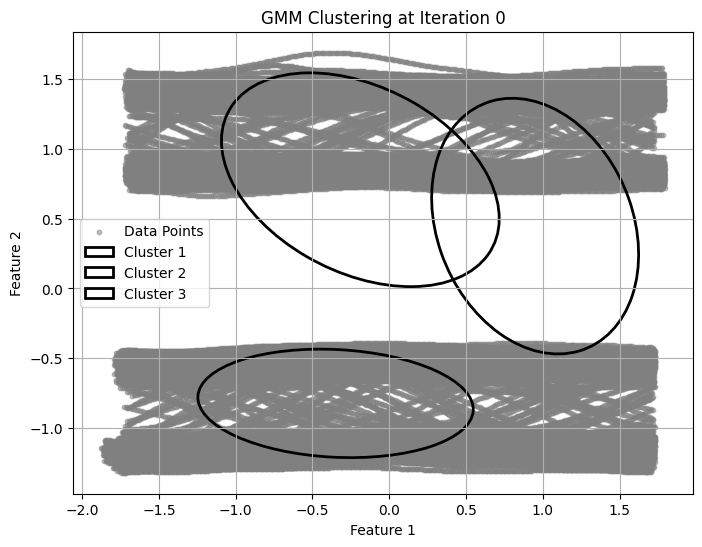

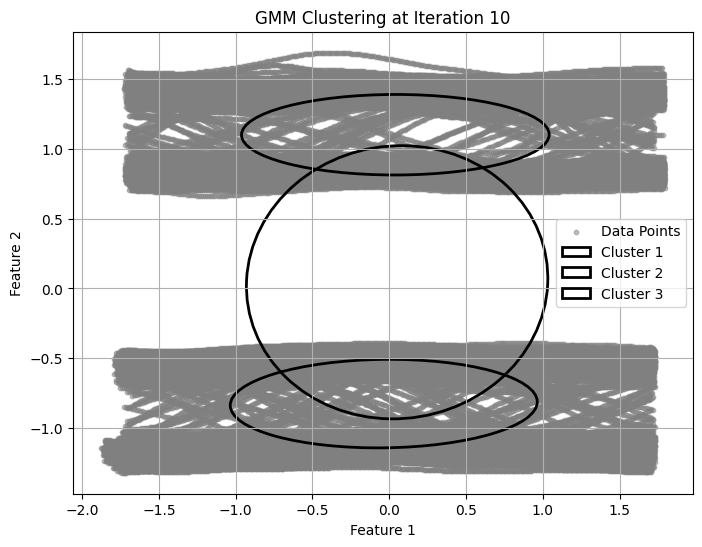

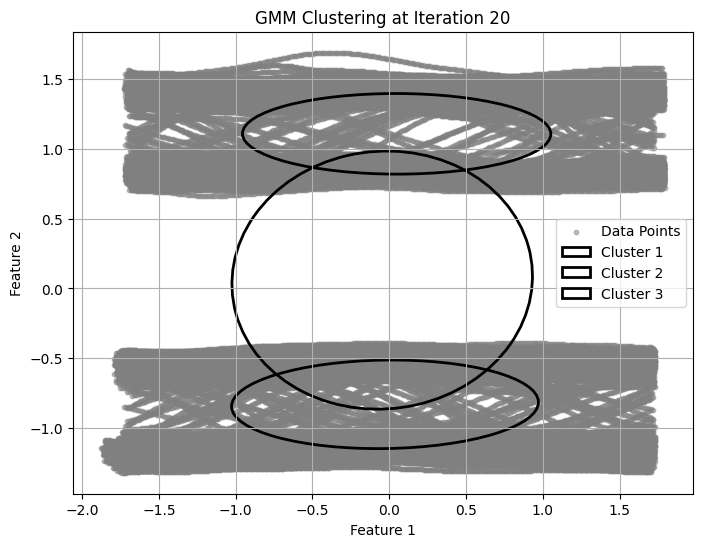

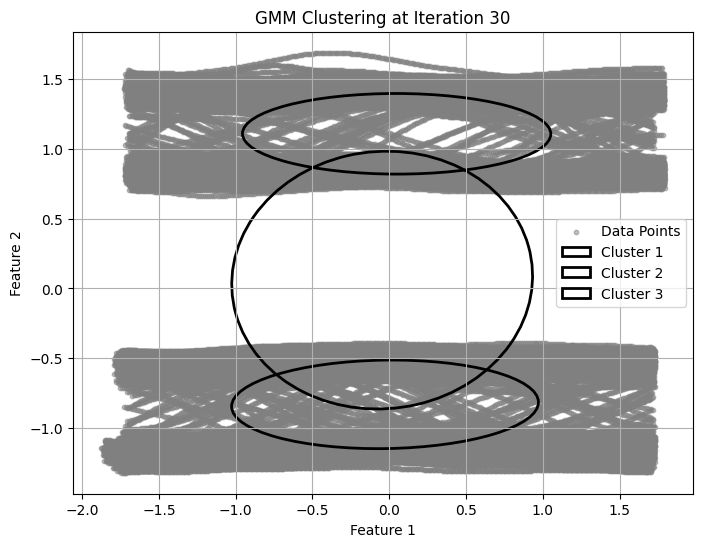

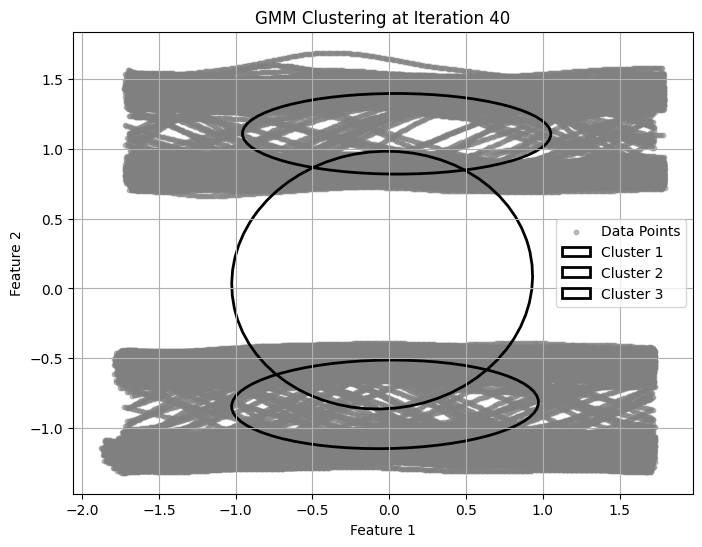

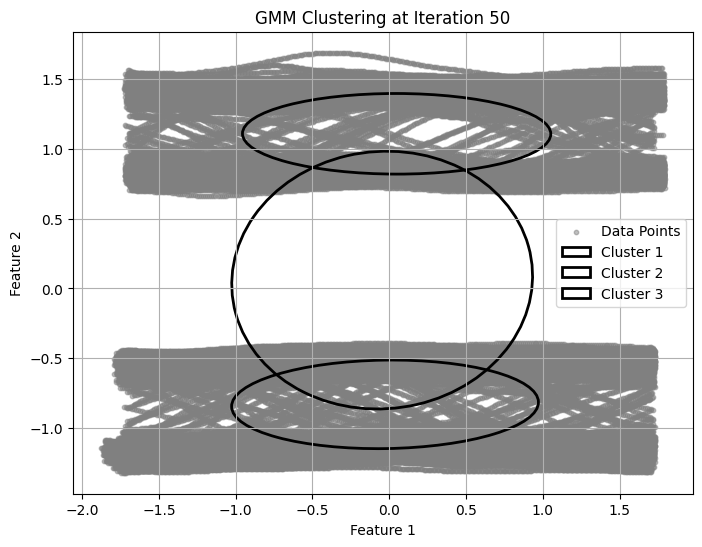

In [68]:
# Call the visualization function
visualize_gmm_progression(X, means_list, covariances_list, weights_list, saved_iterations, feature_idx1=0, feature_idx2=1)
